In [1]:
import pandas as pd
from pathlib import Path

RAW_DIR = Path("../data/raw")
INFORM_FILE = RAW_DIR / "DRMKC-INFORM.xlsx"  # rename after download if needed

xl = pd.ExcelFile(INFORM_FILE)
print("Sheet names:", xl.sheet_names)

for sheet in xl.sheet_names:
    preview = xl.parse(sheet, header=None, nrows=8)
    print(f"\n=== {sheet} === shape: {xl.parse(sheet).shape}")
    print(preview.to_string())

Sheet names: ['Data', 'Indicator Metadata', 'Dataset Metadata']

=== Data === shape: (764, 18)
             0             1                    2                              3            4            5            6        7       8       9       10      11      12      13      14      15      16      17
0  Economy ISO3  Economy Name         Indicator ID                      Indicator  Attribute 1  Attribute 2  Attribute 3  Partner  2015.0  2016.0  2017.0  2018.0  2019.0  2020.0  2021.0  2022.0  2023.0  2024.0
1           AFG   Afghanistan      DRMKC.INFORM.CC  Lack of Coping Capacity Index            -            -            -        -     7.6     7.6     7.4     7.3     7.2     7.2     7.1     7.2     7.1     7.1
2           AFG   Afghanistan      DRMKC.INFORM.HA        Hazard & Exposure Index            -            -            -        -     8.6     8.6     8.6     8.6     8.6     8.7     8.7     8.6     8.7     8.7
3           AFG   Afghanistan  DRMKC.INFORM.INFORM              I

# INFORM Risk Index — Nepal, AI Resilience Dimension

**Source:** EU Joint Research Centre / UNDP Disaster Risk Management Knowledge 
Centre, `DRMKC-INFORM.xlsx`. 191 countries, 2015–2024, updated twice yearly.

**IMPORTANT — scale direction:** this is a RISK index, not a readiness index. 
Higher score = higher risk = worse. This is the opposite convention from every 
other source used this session (Oxford, ITU, GII, AIPI all use higher=better). 
All interpretation below is written accordingly — do not copy sign conventions 
from earlier notebooks without checking.

**Purpose:** Fill the AI Resilience dimension — completely empty until now. 
INFORM measures disaster/humanitarian-crisis risk broadly, not AI-specific 
resilience directly, but it's the best available proxy for the "can systems 
keep running through a crisis" question, and it's explicitly named in the 
project's unpublished planning document as directly relevant (Environment & 
Disaster Management chapter).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIG_DIR = Path("../outputs/figures")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

INFORM_FILE = RAW_DIR / "DRMKC-INFORM.xlsx"

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "font.size": 11, "font.family": "sans-serif",
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.edgecolor": "#333333", "axes.grid": True, "grid.alpha": 0.25,
    "figure.facecolor": "white", "savefig.facecolor": "white",
})
sns.set_style("whitegrid")
NEPAL = "NPL"

## 1. Load and reshape — long format, most recent year (2024) per indicator

In [5]:
raw = pd.read_excel(INFORM_FILE, sheet_name="Data", header=0)
raw.columns = [str(c) for c in raw.columns]
print("Actual columns:", raw.columns.tolist())  # <-- this line tells us the real name

year_col = next(c for c in raw.columns if c.startswith("2024"))
print(f"Using year column: '{year_col}'")

INDICATOR_MAP = {
    "DRMKC.INFORM.INFORM": "INFORM_Risk",
    "DRMKC.INFORM.HA": "Hazard_Exposure",
    "DRMKC.INFORM.VU": "Vulnerability",
    "DRMKC.INFORM.CC": "Lack_Coping_Capacity",
}

wide = raw.pivot_table(index=["Economy ISO3", "Economy Name"], columns="Indicator ID", values=year_col)
wide = wide.rename(columns=INDICATOR_MAP).reset_index().rename(columns={"Economy ISO3": "iso3", "Economy Name": "country"})

print(f"Loaded {len(wide)} economies, {year_col} data")
wide[wide.iso3 == NEPAL]

Actual columns: ['Economy ISO3', 'Economy Name', 'Indicator ID', 'Indicator', 'Attribute 1', 'Attribute 2', 'Attribute 3', 'Partner', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
Using year column: '2024'
Loaded 191 economies, 2024 data


Indicator ID,iso3,country,Lack_Coping_Capacity,Hazard_Exposure,INFORM_Risk,Vulnerability
128,NPL,Nepal,5.4,3.2,4.1,4.1


## 2. Income-adjustment test — remember: higher INFORM score = higher risk

We regress risk on log(GDP) — expect a NEGATIVE correlation (richer countries 
have lower risk). Nepal's residual: positive = worse than income predicts 
(higher risk than expected), negative = better than income predicts (lower 
risk than expected). This is the inverse of every prior notebook's convention.

In [6]:
GDP_FILE = next(RAW_DIR.glob("API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_*.csv"))
GDP_META_FILE = next(RAW_DIR.glob("Metadata_Country_API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_*.csv"))

wb = pd.read_csv(GDP_FILE, skiprows=4)
wb_meta = pd.read_csv(GDP_META_FILE)
real_codes = set(wb_meta.loc[wb_meta["Region"].notna(), "Country Code"])
wb = wb[wb["Country Code"].isin(real_codes)]
year_cols = [c for c in wb.columns if c.isdigit()]

def latest_value(row):
    for y in sorted(year_cols, reverse=True):
        if pd.notna(row[y]):
            return row[y]
    return np.nan

wb["gdp"] = wb.apply(latest_value, axis=1)
gdp_map = dict(zip(wb["Country Code"], wb["gdp"]))

df = wide.copy()
df["gdp"] = df["iso3"].map(gdp_map)
df = df.dropna(subset=["gdp"])
df["log_gdp"] = np.log(df["gdp"])
print(f"n = {len(df)}")

results = {}
for col in ["INFORM_Risk", "Hazard_Exposure", "Vulnerability", "Lack_Coping_Capacity"]:
    sub = df.dropna(subset=[col]).copy()
    slope, intercept, r, p, se = stats.linregress(sub["log_gdp"], sub[col])
    sub["resid"] = sub[col] - (slope * sub["log_gdp"] + intercept)
    nepal_resid = sub.loc[sub.iso3 == NEPAL, "resid"]
    if len(nepal_resid) == 0:
        continue
    nepal_resid = nepal_resid.iloc[0]
    # flip percentile framing: for a risk score, LOWER residual = BETTER (lower risk than expected)
    pct_risk = stats.percentileofscore(sub["resid"], nepal_resid)
    print(f"{col:24s} r={r:.3f} p={p:.4f} n={len(sub):3d} | Nepal residual={nepal_resid:+.3f} "
          f"(risk-percentile {pct_risk:.1f} — LOWER pct = better/lower-risk-than-expected)")
    results[col] = sub

df.to_csv(PROCESSED_DIR / "inform_income_adjusted.csv", index=False)

n = 188
INFORM_Risk              r=-0.780 p=0.0000 n=188 | Nepal residual=-0.767 (risk-percentile 24.5 — LOWER pct = better/lower-risk-than-expected)
Hazard_Exposure          r=-0.452 p=0.0000 n=188 | Nepal residual=-0.956 (risk-percentile 37.8 — LOWER pct = better/lower-risk-than-expected)
Vulnerability            r=-0.796 p=0.0000 n=188 | Nepal residual=-1.195 (risk-percentile 16.0 — LOWER pct = better/lower-risk-than-expected)
Lack_Coping_Capacity     r=-0.892 p=0.0000 n=188 | Nepal residual=-0.422 (risk-percentile 34.6 — LOWER pct = better/lower-risk-than-expected)


## 3. South Asia comparison table

In [7]:
SOUTH_ASIA = ["NPL", "IND", "PAK", "BGD", "LKA", "BTN", "AFG", "MDV"]
NAMES = {"NPL": "Nepal", "IND": "India", "PAK": "Pakistan", "BGD": "Bangladesh",
         "LKA": "Sri Lanka", "BTN": "Bhutan", "AFG": "Afghanistan", "MDV": "Maldives"}

sa = df[df.iso3.isin(SOUTH_ASIA)].copy()
sa["Country"] = sa["iso3"].map(NAMES)
sa = sa[["Country", "gdp", "INFORM_Risk", "Hazard_Exposure", "Vulnerability", "Lack_Coping_Capacity"]].sort_values("INFORM_Risk")

sa.to_csv(PROCESSED_DIR / "south_asia_inform_comparison.csv", index=False)
with open(PROCESSED_DIR / "south_asia_inform_comparison.md", "w") as f:
    f.write(sa.to_markdown(index=False))
sa

Indicator ID,Country,gdp,INFORM_Risk,Hazard_Exposure,Vulnerability,Lack_Coping_Capacity
108,Maldives,28554.894567,2.2,1.5,2.0,3.7
25,Bhutan,19594.002838,2.8,1.5,3.7,4.0
100,Sri Lanka,17065.029864,3.1,2.7,2.7,3.9
128,Nepal,6175.158972,4.1,3.2,4.1,5.4
76,India,11747.916044,5.3,7.4,4.7,4.2
14,Bangladesh,10153.708379,5.7,6.9,5.5,4.8
132,Pakistan,6573.416134,6.1,7.2,5.9,5.3
0,Afghanistan,2236.199073,8.1,8.7,8.5,7.1


## 4. Figure — bubble chart: Hazard & Exposure vs. Coping Capacity, sized by Vulnerability

INFORM's own methodology is genuinely three-dimensional (Risk = Hazard^1/3 × 
Vulnerability^1/3 × CopingCapacity^1/3) — this chart represents that structure 
directly rather than collapsing it to one number. New chart type for this 
project: bubble/sized-scatter, not used before.

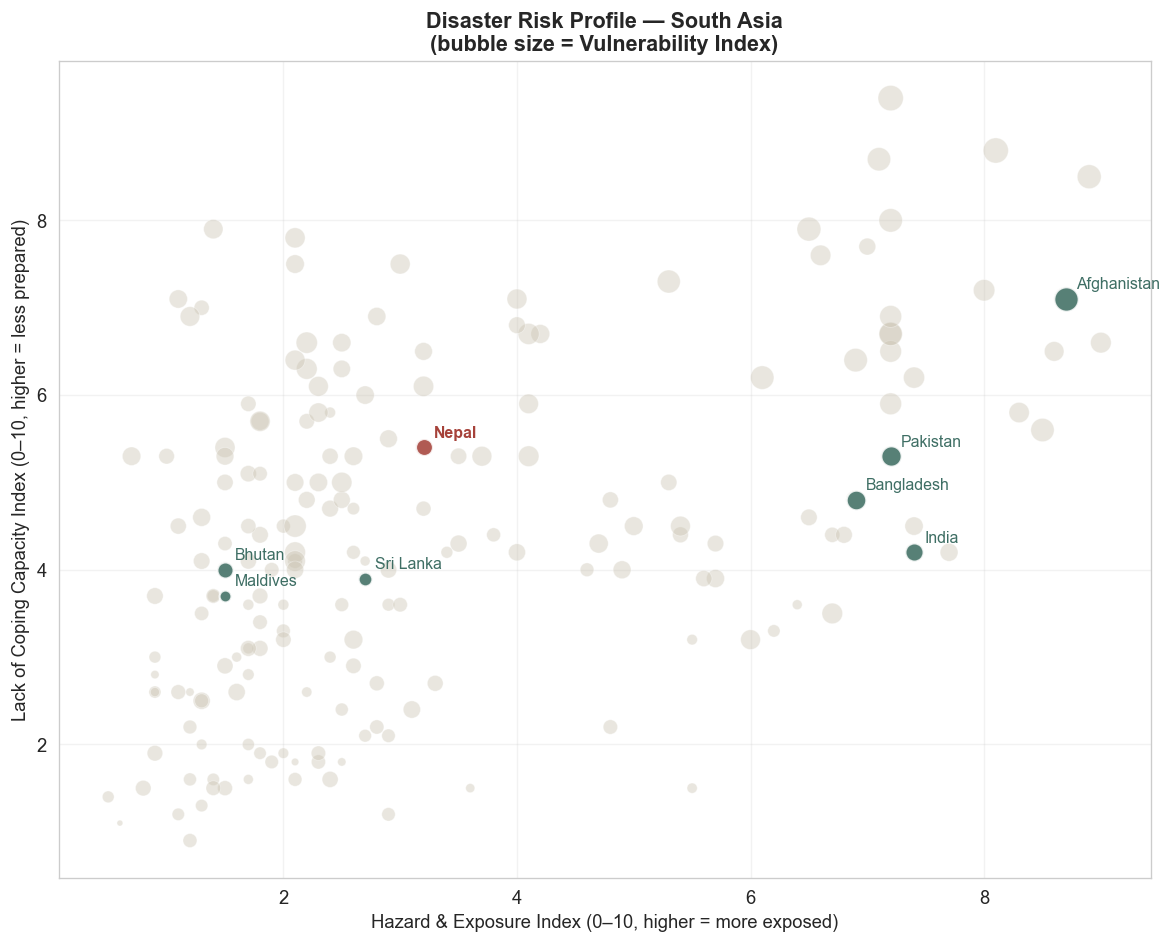

In [8]:
plot_df = df.dropna(subset=["Hazard_Exposure", "Lack_Coping_Capacity", "Vulnerability"])

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(plot_df["Hazard_Exposure"], plot_df["Lack_Coping_Capacity"],
           s=plot_df["Vulnerability"]*25, color="#c9c2b0", alpha=0.4, zorder=2, edgecolor="white", linewidth=0.5)

for code in SOUTH_ASIA:
    row = df[df.iso3 == code]
    if len(row) == 0 or row["Hazard_Exposure"].isna().iloc[0]:
        continue
    row = row.iloc[0]
    color = "#A6423A" if code == NEPAL else "#3E6E64"
    ax.scatter(row.Hazard_Exposure, row.Lack_Coping_Capacity, s=row.Vulnerability*25,
               color=color, alpha=0.85, zorder=3, edgecolor="white", linewidth=1.2)
    ax.annotate(NAMES[code], (row.Hazard_Exposure, row.Lack_Coping_Capacity),
                xytext=(6, 6), textcoords="offset points", fontsize=9.5,
                fontweight="bold" if code == NEPAL else "normal", color=color)

ax.set_xlabel("Hazard & Exposure Index (0–10, higher = more exposed)")
ax.set_ylabel("Lack of Coping Capacity Index (0–10, higher = less prepared)")
ax.set_title("Disaster Risk Profile — South Asia\n(bubble size = Vulnerability Index)")
fig.tight_layout()
fig.savefig(FIG_DIR / "inform_risk_profile_bubble.png", bbox_inches="tight")
plt.show()